1. Dataset & Problem Understanding

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Đọc dataset
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

# ===== THÔNG TIN DATASET =====
print("===== THÔNG TIN DATASET =====")
print("Tên dataset: IBM Telco Customer Churn Dataset")
print("Nguồn: Kaggle")
print("File:", file_path)
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

# ===== CÁC CỘT =====
print("\n===== CÁC CỘT TRONG DATASET =====")
print(df.columns.tolist())

# ===== KIỂU DỮ LIỆU =====
print("\n===== KIỂU DỮ LIỆU =====")
display(df.dtypes)

# ===== 5 DÒNG ĐẦU =====
print("\n===== 5 DÒNG ĐẦU TIÊN =====")
display(df.head())

===== THÔNG TIN DATASET =====
Tên dataset: IBM Telco Customer Churn Dataset
Nguồn: Kaggle
File: WA_Fn-UseC_-Telco-Customer-Churn.csv
Số dòng: 7043
Số cột: 21

===== CÁC CỘT TRONG DATASET =====
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

===== KIỂU DỮ LIỆU =====


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


===== 5 DÒNG ĐẦU TIÊN =====


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


2. EDA(exploratory data analysis)

===== THÔNG TIN DỮ LIỆU =====
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



===== GIÁ TRỊ THIẾU =====


,Missing Values,Missing (%)
customerID,0,0.00
gender,0,0.00
SeniorCitizen,0,0.00
Partner,0,0.00
Dependents,0,0.00
tenure,0,0.00
PhoneService,0,0.00
MultipleLines,0,0.00
InternetService,0,0.00
OnlineSecurity,0,0.00



===== DÒNG TRÙNG =====
Số dòng trùng: 0

===== PHÂN BỐ CHURN =====
Churn
No     5174
Yes    1869
Name: count, dtype: int64

===== TỶ LỆ CHURN (%) =====
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


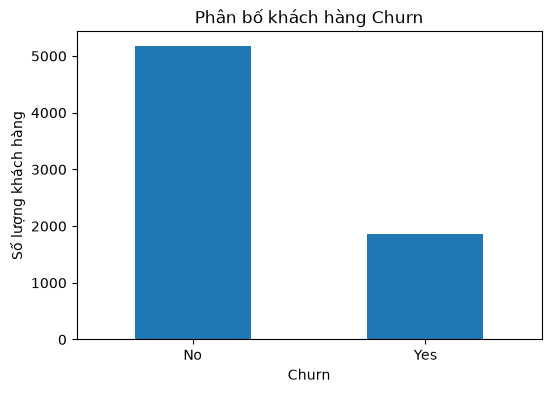

In [41]:
# ===== TỔNG QUAN DỮ LIỆU =====
print("===== THÔNG TIN DỮ LIỆU =====")
df.info()

# ===== THỐNG KÊ MÔ TẢ =====
print("\n===== THỐNG KÊ CÁC BIẾN NUMERICAL =====")
display(df.describe())

# ===== KIỂM TRA GIÁ TRỊ THIẾU =====
print("\n===== GIÁ TRỊ THIẾU =====")

# Kiểm tra missing trong dữ liệu gốc
missing_values = df.isnull().sum()

# Kiểm tra riêng TotalCharges sau khi chuyển sang numeric
totalcharges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
missing_values["TotalCharges"] = totalcharges_numeric.isnull().sum()

display(
    pd.DataFrame({
        "Missing Values": missing_values,
        "Missing (%)": (missing_values / len(df) * 100).round(2)
    })
)

# ===== KIỂM TRA DÒNG TRÙNG =====
print("\n===== DÒNG TRÙNG =====")
print("Số dòng trùng:", df.duplicated().sum())

# ===== PHÂN BỐ TARGET =====
print("\n===== PHÂN BỐ CHURN =====")
print(df["Churn"].value_counts())

print("\n===== TỶ LỆ CHURN (%) =====")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

# ===== BIỂU ĐỒ PHÂN BỐ CHURN =====
plt.figure(figsize=(6, 4))
df["Churn"].value_counts().plot(kind="bar")
plt.title("Phân bố khách hàng Churn")
plt.xlabel("Churn")
plt.ylabel("Số lượng khách hàng")
plt.xticks(rotation=0)
plt.show()

3. xac dinh x va y 

In [42]:
# ===== XÁC ĐỊNH TARGET (y) =====
TARGET = "Churn"

if TARGET not in df.columns:
    raise ValueError(f"Không tìm thấy target '{TARGET}' trong dataset.")

# ===== XÁC ĐỊNH FEATURES (X) =====
# customerID chỉ là mã định danh, không mang thông tin dự đoán
excluded_columns = ["customerID", TARGET]

feature_columns = [
    column for column in df.columns
    if column not in excluded_columns
]

X = df[feature_columns].copy()
y = df[TARGET].copy()

# ===== PHÂN LOẠI FEATURES =====
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

# ===== HIỂN THỊ KẾT QUẢ =====
print("===== TARGET (y) =====")
print("Tên target:", TARGET)
print("Kiểu dữ liệu:", y.dtype)
print("Các giá trị của target:", y.unique())

print("\n===== FEATURES (X) =====")
print("Số lượng features:", len(feature_columns))
print("Danh sách features:")
print(feature_columns)

print("\n===== PHÂN LOẠI FEATURES =====")
print("Numerical features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

print("\n===== KIỂU DỮ LIỆU CỦA FEATURES =====")
display(
    pd.DataFrame({
        "Feature": X.columns,
        "Data Type": X.dtypes.astype(str).values,
        "Feature Type": [
            "Numerical" if column in numeric_features
            else "Categorical"
            for column in X.columns
        ]
    })
)

print("\n===== KÍCH THƯỚC =====")
print("X shape:", X.shape)
print("y shape:", y.shape)

===== TARGET (y) =====
Tên target: Churn
Kiểu dữ liệu: str
Các giá trị của target: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

===== FEATURES (X) =====
Số lượng features: 19
Danh sách features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

===== PHÂN LOẠI FEATURES =====
Numerical features: 3
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical features: 16
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']

===== KIỂU DỮ LIỆU CỦA FEATURES =====


C:\Users\Admin\AppData\Local\Temp\ipykernel_10432\364879490.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


,Feature,Data Type,Feature Type
0,gender,str,Categorical
1,SeniorCitizen,int64,Numerical
2,Partner,str,Categorical
3,Dependents,str,Categorical
4,tenure,int64,Numerical
5,PhoneService,str,Categorical
6,MultipleLines,str,Categorical
7,InternetService,str,Categorical
8,OnlineSecurity,str,Categorical
9,OnlineBackup,str,Categorical



===== KÍCH THƯỚC =====
X shape: (7043, 19)
y shape: (7043,)


4. preprocessing 

In [43]:
# ===== SAO CHÉP DỮ LIỆU =====
X_processed = X.copy()
y_processed = y.copy()

# ===== XỬ LÝ KIỂU DỮ LIỆU =====
# TotalCharges có thể chứa giá trị rỗng nên cần chuyển sang numeric
if "TotalCharges" in X_processed.columns:
    X_processed["TotalCharges"] = pd.to_numeric(
        X_processed["TotalCharges"],
        errors="coerce"
    )

# ===== XỬ LÝ TARGET =====
# Chuyển Churn từ Yes/No sang 1/0
y_processed = y_processed.map({
    "No": 0,
    "Yes": 1
})

if y_processed.isnull().any():
    raise ValueError("Target chứa giá trị không hợp lệ.")

# ===== PHÂN LOẠI FEATURES =====
numeric_features = X_processed.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_processed.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

# ===== NUMERICAL PREPROCESSING =====
# Missing numerical values → median
# Scaling → chuẩn hóa dữ liệu
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ===== CATEGORICAL PREPROCESSING =====
# Missing categorical values → giá trị xuất hiện nhiều nhất
# Categorical → One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ===== TẠO PREPROCESSING PIPELINE =====
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# ===== KIỂM TRA PREPROCESSING =====
print("===== PREPROCESSING =====")
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

print("\nSố numerical features:", len(numeric_features))
print("Số categorical features:", len(categorical_features))

print("\nTarget sau khi encoding:")
print(y_processed.value_counts())

print("\nPreprocessing pipeline đã được tạo.")
print("Chưa fit/transform dữ liệu ở bước này để tránh data leakage.")

===== PREPROCESSING =====
Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Số numerical features: 4
Số categorical features: 15

Target sau khi encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64

Preprocessing pipeline đã được tạo.
Chưa fit/transform dữ liệu ở bước này để tránh data leakage.


C:\Users\Admin\AppData\Local\Temp\ipykernel_10432\2078658831.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_processed.select_dtypes(


5. chia train/test 

In [44]:
# ===== CHIA TRAIN / VALIDATION / TEST =====
# 80% dữ liệu cho Train + Validation, 20% giữ lại làm Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_processed,
    y_processed,
    test_size=0.20,
    random_state=42,
    stratify=y_processed
)

# Chia 80% còn lại thành Train 60% và Validation 20% tổng dữ liệu
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

# ===== HIỂN THỊ KẾT QUẢ =====
print("===== DATA SPLIT =====")
print("Tổng số dữ liệu:", len(X_processed))

print("\nTrain set:")
print("Số dòng:", len(X_train))
print("Tỷ lệ:", f"{len(X_train) / len(X_processed):.0%}")

print("\nValidation set:")
print("Số dòng:", len(X_val))
print("Tỷ lệ:", f"{len(X_val) / len(X_processed):.0%}")

print("\nTest set:")
print("Số dòng:", len(X_test))
print("Tỷ lệ:", f"{len(X_test) / len(X_processed):.0%}")

# ===== KIỂM TRA PHÂN BỐ TARGET =====
print("\n===== PHÂN BỐ CHURN =====")

print("Train:")
print(
    (y_train.value_counts(normalize=True) * 100)
    .round(2)
    .rename({0: "No Churn", 1: "Churn"})
)

print("\nValidation:")
print(
    (y_val.value_counts(normalize=True) * 100)
    .round(2)
    .rename({0: "No Churn", 1: "Churn"})
)

print("\nTest:")
print(
    (y_test.value_counts(normalize=True) * 100)
    .round(2)
    .rename({0: "No Churn", 1: "Churn"})
)

print("\nTest set sẽ chỉ được sử dụng để đánh giá mô hình cuối cùng.")

===== DATA SPLIT =====
Tổng số dữ liệu: 7043

Train set:
Số dòng: 4225
Tỷ lệ: 60%

Validation set:
Số dòng: 1409
Tỷ lệ: 20%

Test set:
Số dòng: 1409
Tỷ lệ: 20%

===== PHÂN BỐ CHURN =====
Train:
Churn
No Churn    73.47
Churn       26.53
Name: proportion, dtype: float64

Validation:
Churn
No Churn    73.46
Churn       26.54
Name: proportion, dtype: float64

Test:
Churn
No Churn    73.46
Churn       26.54
Name: proportion, dtype: float64

Test set sẽ chỉ được sử dụng để đánh giá mô hình cuối cùng.


6. train xgboost 

In [45]:
# ===== XÂY DỰNG XGBOOST PIPELINE =====
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        eval_metric="logloss"
    ))
])

# ===== HUẤN LUYỆN MÔ HÌNH =====
# Chỉ sử dụng TRAIN set
xgb_model.fit(X_train, y_train)

# ===== DỰ ĐOÁN =====
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# ===== KẾT QUẢ BAN ĐẦU =====
print("===== XGBOOST MODEL =====")
print("XGBoost đã được huấn luyện thành công.")

print("\n10 giá trị thực tế đầu tiên:")
print(y_test.iloc[:10].values)

print("\n10 giá trị dự đoán đầu tiên:")
print(y_pred_xgb[:10])

print("\n10 xác suất Churn đầu tiên:")
print(np.round(y_prob_xgb[:10], 4))

===== XGBOOST MODEL =====
XGBoost đã được huấn luyện thành công.

10 giá trị thực tế đầu tiên:
[0 0 0 0 0 0 0 0 0 1]

10 giá trị dự đoán đầu tiên:
[0 1 0 0 0 1 1 0 0 0]

10 xác suất Churn đầu tiên:
[0.0279 0.8838 0.0936 0.2954 0.0059 0.6642 0.5885 0.1682 0.01   0.3482]


7. train decision tree 

In [46]:
# ===== XÂY DỰNG DECISION TREE PIPELINE =====
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

# ===== HUẤN LUYỆN MÔ HÌNH =====
# Chỉ sử dụng TRAIN set
dt_model.fit(X_train, y_train)

# ===== DỰ ĐOÁN =====
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# ===== KẾT QUẢ BAN ĐẦU =====
print("===== DECISION TREE MODEL =====")
print("Decision Tree đã được huấn luyện thành công.")

print("\n10 giá trị thực tế đầu tiên:")
print(y_test.iloc[:10].values)

print("\n10 giá trị dự đoán đầu tiên:")
print(y_pred_dt[:10])

print("\n10 xác suất Churn đầu tiên:")
print(np.round(y_prob_dt[:10], 4))

===== DECISION TREE MODEL =====
Decision Tree đã được huấn luyện thành công.

10 giá trị thực tế đầu tiên:
[0 0 0 0 0 0 0 0 0 1]

10 giá trị dự đoán đầu tiên:
[0 1 0 1 0 1 0 1 0 0]

10 xác suất Churn đầu tiên:
[0. 1. 0. 1. 0. 1. 0. 1. 0. 0.]


8. train random forest 

In [47]:
# ===== XÂY DỰNG RANDOM FOREST PIPELINE =====
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# ===== HUẤN LUYỆN MÔ HÌNH =====
# Chỉ sử dụng TRAIN set
rf_model.fit(X_train, y_train)

# ===== DỰ ĐOÁN =====
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# ===== KẾT QUẢ BAN ĐẦU =====
print("===== RANDOM FOREST MODEL =====")
print("Random Forest đã được huấn luyện thành công.")

print("\n10 giá trị thực tế đầu tiên:")
print(y_test.iloc[:10].values)

print("\n10 giá trị dự đoán đầu tiên:")
print(y_pred_rf[:10])

print("\n10 xác suất Churn đầu tiên:")
print(np.round(y_prob_rf[:10], 4))

===== RANDOM FOREST MODEL =====
Random Forest đã được huấn luyện thành công.

10 giá trị thực tế đầu tiên:
[0 0 0 0 0 0 0 0 0 1]

10 giá trị dự đoán đầu tiên:
[0 1 0 0 0 0 0 0 0 1]

10 xác suất Churn đầu tiên:
[0.   0.69 0.03 0.29 0.05 0.43 0.36 0.12 0.   0.54]


9. soft voting ensemble( mô hình gộp )

In [48]:
# ===== XÂY DỰNG VOTING CLASSIFIER =====
voting_model = VotingClassifier(
    estimators=[
        ("xgboost", xgb_model),
        ("decision_tree", dt_model),
        ("random_forest", rf_model)
    ],
    voting="soft"
)

# ===== HUẤN LUYỆN VOTING MODEL =====
# Chỉ sử dụng TRAIN set
voting_model.fit(X_train, y_train)

# ===== DỰ ĐOÁN =====
y_pred_voting = voting_model.predict(X_test)
y_prob_voting = voting_model.predict_proba(X_test)[:, 1]

# ===== KẾT QUẢ BAN ĐẦU =====
print("===== VOTING MODEL =====")
print("Voting Classifier (Soft Voting) đã được huấn luyện thành công.")

print("\n10 giá trị thực tế đầu tiên:")
print(y_test.iloc[:10].values)

print("\n10 giá trị dự đoán đầu tiên:")
print(y_pred_voting[:10])

print("\n10 xác suất Churn đầu tiên:")
print(np.round(y_prob_voting[:10], 4))

===== VOTING MODEL =====
Voting Classifier (Soft Voting) đã được huấn luyện thành công.

10 giá trị thực tế đầu tiên:
[0 0 0 0 0 0 0 0 0 1]

10 giá trị dự đoán đầu tiên:
[0 1 0 1 0 1 0 0 0 0]

10 xác suất Churn đầu tiên:
[0.0093 0.8579 0.0412 0.5285 0.0186 0.6981 0.3162 0.4294 0.0033 0.2961]


10. danh gia va so sanh cac model 

In [49]:
# ===== HÀM ĐÁNH GIÁ MODEL =====
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }


# ===== DỰ ĐOÁN TRÊN VALIDATION SET =====
y_pred_xgb_val = xgb_model.predict(X_val)
y_prob_xgb_val = xgb_model.predict_proba(X_val)[:, 1]

y_pred_dt_val = dt_model.predict(X_val)
y_prob_dt_val = dt_model.predict_proba(X_val)[:, 1]

y_pred_rf_val = rf_model.predict(X_val)
y_prob_rf_val = rf_model.predict_proba(X_val)[:, 1]

y_pred_voting_val = voting_model.predict(X_val)
y_prob_voting_val = voting_model.predict_proba(X_val)[:, 1]


# ===== TÍNH TOÁN CÁC CHỈ SỐ =====
results = pd.DataFrame([
    evaluate_model("XGBoost", y_val, y_pred_xgb_val, y_prob_xgb_val),
    evaluate_model("Decision Tree", y_val, y_pred_dt_val, y_prob_dt_val),
    evaluate_model("Random Forest", y_val, y_pred_rf_val, y_prob_rf_val),
    evaluate_model("Voting", y_val, y_pred_voting_val, y_prob_voting_val)
])

# ===== HIỂN THỊ BẢNG SO SÁNH =====
print("===== MODEL COMPARISON - VALIDATION SET =====")
display(results.round(4))

print("\nTest set chưa được sử dụng.")

===== MODEL COMPARISON - VALIDATION SET =====


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,0.7977,0.6606,0.4893,0.5622,0.8371
1,Decision Tree,0.7374,0.5053,0.5107,0.5080,0.6645
2,Random Forest,0.7814,0.6146,0.4733,0.5347,0.8120
3,Voting,0.7672,0.5701,0.5000,0.5328,0.8151



Test set chưa được sử dụng.


11. bieu do so sanh 

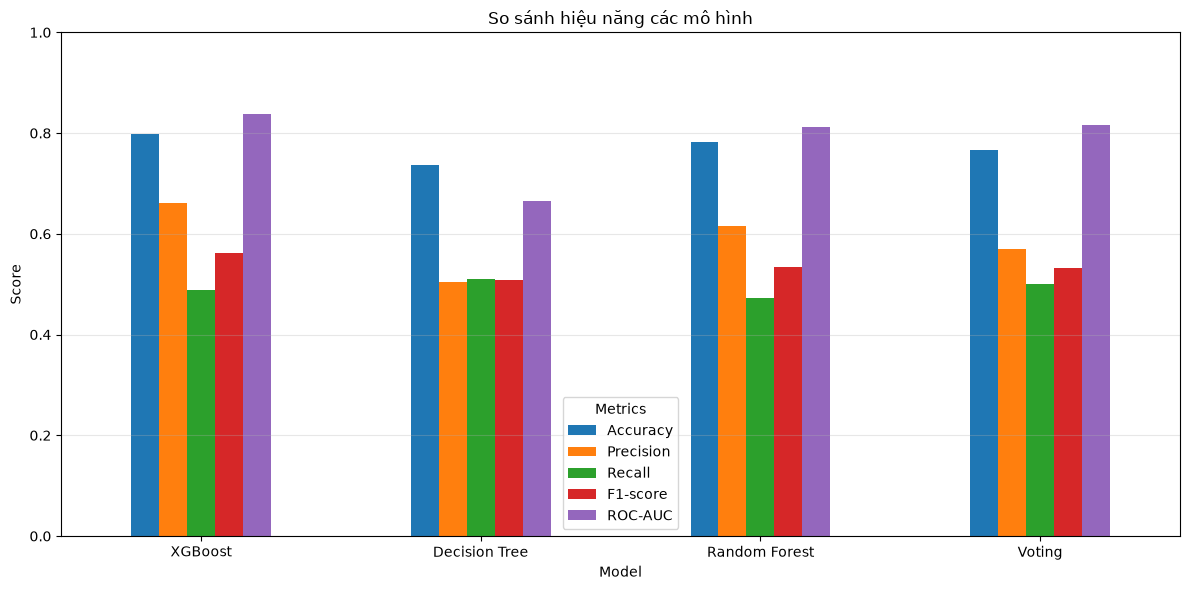

In [50]:
# ===== CHUẨN BỊ DỮ LIỆU VẼ BIỂU ĐỒ =====
plot_data = results.set_index("Model")

# ===== VẼ BIỂU ĐỒ SO SÁNH =====
ax = plot_data[
    ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("So sánh hiệu năng các mô hình")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

12. confusion matrix 

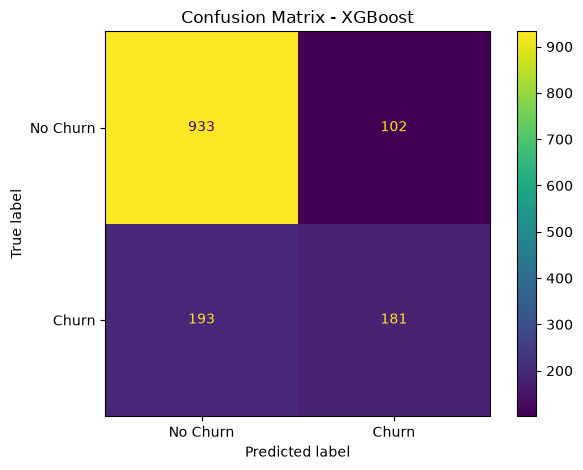

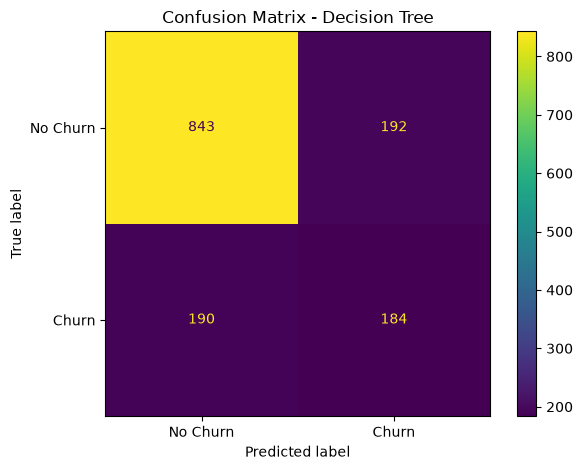

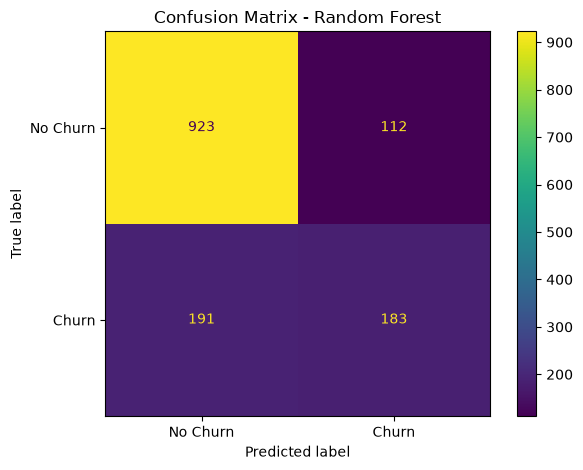

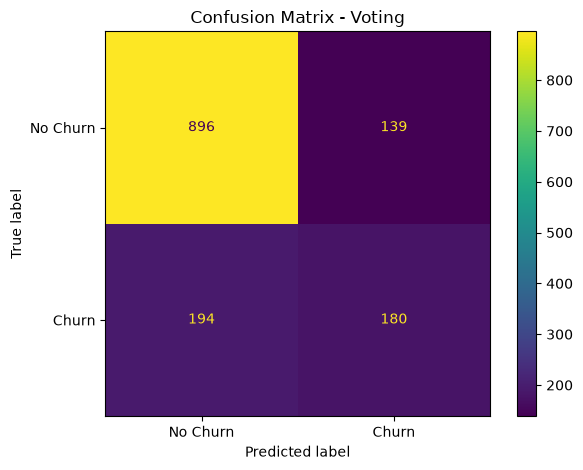

In [51]:
# ===== CHUẨN BỊ CÁC MODEL VÀ DỰ ĐOÁN =====
model_predictions = {
    "XGBoost": y_pred_xgb,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Voting": y_pred_voting
}

# ===== VẼ CONFUSION MATRIX CHO TỪNG MODEL =====
for model_name, y_pred in model_predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

13. error analysis

In [52]:

# Phân tích lỗi dựa trên Confusion Matrix của các mô hình
model_predictions = {
    "XGBoost": y_pred_xgb,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Voting": y_pred_voting
}

error_analysis = []

for model_name, y_pred in model_predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    error_analysis.append({
        "Model": model_name,
        "True Negative (TN)": tn,
        "False Positive (FP)": fp,
        "False Negative (FN)": fn,
        "True Positive (TP)": tp,
        "FN Rate": round(fn / (fn + tp), 4),
        "FP Rate": round(fp / (fp + tn), 4)
    })

error_df = pd.DataFrame(error_analysis)

print("===== ERROR ANALYSIS =====")
display(error_df)

# ===== SO SÁNH FN VÀ FP =====
print("\n===== NHẬN XÉT LỖI =====")

for _, row in error_df.iterrows():
    print(
        f"{row['Model']}: "
        f"FN = {row['False Negative (FN)']}, "
        f"FP = {row['False Positive (FP)']}"
    )

print("\nFN: Khách hàng thực sự Churn nhưng mô hình dự đoán No Churn.")
print("FP: Khách hàng thực sự No Churn nhưng mô hình dự đoán Churn.")

===== ERROR ANALYSIS =====


,Model,True Negative (TN),False Positive (FP),False Negative (FN),True Positive (TP),FN Rate,FP Rate
0,XGBoost,933,102,193,181,0.5160,0.0986
1,Decision Tree,843,192,190,184,0.5080,0.1855
2,Random Forest,923,112,191,183,0.5107,0.1082
3,Voting,896,139,194,180,0.5187,0.1343



===== NHẬN XÉT LỖI =====
XGBoost: FN = 193, FP = 102
Decision Tree: FN = 190, FP = 192
Random Forest: FN = 191, FP = 112
Voting: FN = 194, FP = 139

FN: Khách hàng thực sự Churn nhưng mô hình dự đoán No Churn.
FP: Khách hàng thực sự No Churn nhưng mô hình dự đoán Churn.


14. xử lý imbalance data 

In [53]:
# Tính tỷ lệ giữa lớp No Churn và Churn trên TRAIN SET
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("===== IMBALANCE DATA =====")
print(f"No Churn: {negative_count}")
print(f"Churn: {positive_count}")
print(f"Tỷ lệ No Churn / Churn: {scale_pos_weight:.2f}")

# ===== XGBOOST =====
xgb_imbalance = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    ))
])

# ===== DECISION TREE =====
dt_imbalance = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

# ===== RANDOM FOREST =====
rf_imbalance = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

print("\n===== XỬ LÝ IMBALANCE ĐÃ ĐƯỢC THIẾT LẬP =====")
print("XGBoost       → scale_pos_weight")
print("Decision Tree → class_weight='balanced'")
print("Random Forest → class_weight='balanced'")
print("\nChưa tuning hyperparameter ở bước này.")

===== IMBALANCE DATA =====
No Churn: 3104
Churn: 1121
Tỷ lệ No Churn / Churn: 2.77

===== XỬ LÝ IMBALANCE ĐÃ ĐƯỢC THIẾT LẬP =====
XGBoost       → scale_pos_weight
Decision Tree → class_weight='balanced'
Random Forest → class_weight='balanced'

Chưa tuning hyperparameter ở bước này.


15. model tuning 

In [54]:

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# StratifiedKFold giữ tỷ lệ Churn / No Churn trong mỗi fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ===== XGBOOST =====
xgb_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb_imbalance,
    param_distributions=xgb_params,
    n_iter=10,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)


# ===== DECISION TREE =====
dt_params = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__criterion": ["gini", "entropy"]
}

dt_search = RandomizedSearchCV(
    dt_imbalance,
    param_distributions=dt_params,
    n_iter=10,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

dt_search.fit(X_train, y_train)


# ===== RANDOM FOREST =====
rf_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf_imbalance,
    param_distributions=rf_params,
    n_iter=10,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)


# ===== KẾT QUẢ TUNING =====
print("===== MODEL TUNING RESULTS =====")

print("\nXGBoost")
print("Best F1 (CV):", round(xgb_search.best_score_, 4))
print("Best Parameters:", xgb_search.best_params_)

print("\nDecision Tree")
print("Best F1 (CV):", round(dt_search.best_score_, 4))
print("Best Parameters:", dt_search.best_params_)

print("\nRandom Forest")
print("Best F1 (CV):", round(rf_search.best_score_, 4))
print("Best Parameters:", rf_search.best_params_)

===== MODEL TUNING RESULTS =====

XGBoost
Best F1 (CV): 0.6332
Best Parameters: {'model__subsample': 0.7, 'model__n_estimators': 100, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}

Decision Tree
Best F1 (CV): 0.6165
Best Parameters: {'model__min_samples_split': 10, 'model__min_samples_leaf': 10, 'model__max_depth': 3, 'model__criterion': 'entropy'}

Random Forest
Best F1 (CV): 0.6327
Best Parameters: {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 5, 'model__max_features': 'log2', 'model__max_depth': 15}


16. threshold tuning 

In [55]:

import numpy as np
from sklearn.metrics import f1_score

# Lấy model tốt nhất sau RandomizedSearchCV
tuned_models = {
    "XGBoost": xgb_search.best_estimator_,
    "Decision Tree": dt_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_
}

threshold_results = []

# Tìm threshold tốt nhất dựa trên Validation Set
thresholds = np.arange(0.10, 0.91, 0.05)

for model_name, model in tuned_models.items():

    y_val_prob = model.predict_proba(X_val)[:, 1]

    best_threshold = 0.5
    best_f1 = 0

    for threshold in thresholds:
        y_val_pred = (y_val_prob >= threshold).astype(int)
        f1 = f1_score(y_val, y_val_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    threshold_results.append({
        "Model": model_name,
        "Best Threshold": best_threshold,
        "Best Validation F1": round(best_f1, 4)
    })

threshold_df = pd.DataFrame(threshold_results)

print("===== THRESHOLD TUNING =====")
display(threshold_df)

===== THRESHOLD TUNING =====


,Model,Best Threshold,Best Validation F1
0,XGBoost,0.55,0.6306
1,Decision Tree,0.40,0.6080
2,Random Forest,0.60,0.6235


17. new soft voting 

In [56]:

# Lấy các model tốt nhất sau Model Tuning
xgb_tuned = xgb_search.best_estimator_
dt_tuned = dt_search.best_estimator_
rf_tuned = rf_search.best_estimator_

# ===== TẠO SOFT VOTING MỚI =====
voting_tuned = VotingClassifier(
    estimators=[
        ("xgboost", xgb_tuned),
        ("decision_tree", dt_tuned),
        ("random_forest", rf_tuned)
    ],
    voting="soft"
)

# ===== HUẤN LUYỆN =====
voting_tuned.fit(X_train, y_train)

# ===== DỰ ĐOÁN XÁC SUẤT TRÊN VALIDATION =====
y_val_prob_voting_tuned = voting_tuned.predict_proba(X_val)[:, 1]

# Tìm threshold tốt nhất cho Voting mới
thresholds = np.arange(0.10, 0.91, 0.05)

best_threshold_voting = 0.5
best_f1_voting = 0

for threshold in thresholds:
    y_val_pred = (y_val_prob_voting_tuned >= threshold).astype(int)
    f1 = f1_score(y_val, y_val_pred)

    if f1 > best_f1_voting:
        best_f1_voting = f1
        best_threshold_voting = threshold

# ===== KẾT QUẢ VALIDATION =====
y_val_pred_voting_tuned = (
    y_val_prob_voting_tuned >= best_threshold_voting
).astype(int)

print("===== IMPROVED SOFT VOTING =====")
print("Voting Baseline → XGBoost + Decision Tree + Random Forest")
print("Voting Improved  → Tuned XGBoost + Tuned Decision Tree + Tuned Random Forest")

print("\nBest Threshold:", best_threshold_voting)
print("Validation Accuracy:", round(
    accuracy_score(y_val, y_val_pred_voting_tuned), 4
))
print("Validation Precision:", round(
    precision_score(y_val, y_val_pred_voting_tuned), 4
))
print("Validation Recall:", round(
    recall_score(y_val, y_val_pred_voting_tuned), 4
))
print("Validation F1:", round(
    f1_score(y_val, y_val_pred_voting_tuned), 4
))
print("Validation ROC-AUC:", round(
    roc_auc_score(y_val, y_val_prob_voting_tuned), 4
))

===== IMPROVED SOFT VOTING =====
Voting Baseline → XGBoost + Decision Tree + Random Forest
Voting Improved  → Tuned XGBoost + Tuned Decision Tree + Tuned Random Forest

Best Threshold: 0.6000000000000002
Validation Accuracy: 0.7921
Validation Precision: 0.5918
Validation Recall: 0.6979
Validation F1: 0.6405
Validation ROC-AUC: 0.8347


18. so sanh baseline va improved model 

In [57]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

comparison_results = []

# ===== BASELINE MODELS =====
baseline_models = {
    "XGBoost Baseline": (xgb_model, y_pred_xgb),
    "Decision Tree Baseline": (dt_model, y_pred_dt),
    "Random Forest Baseline": (rf_model, y_pred_rf),
    "Soft Voting Baseline": (voting_model, y_pred_voting)
}

for name, (model, y_pred) in baseline_models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    comparison_results.append({
        "Model": name,
        "Type": "Baseline",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })


# ===== IMPROVED MODELS =====
improved_models = {
    "XGBoost Improved": (
        xgb_search.best_estimator_,
        best_thresholds["XGBoost"]
    ),
    "Decision Tree Improved": (
        dt_search.best_estimator_,
        best_thresholds["Decision Tree"]
    ),
    "Random Forest Improved": (
        rf_search.best_estimator_,
        best_thresholds["Random Forest"]
    ),
    "Soft Voting Improved": (
        voting_tuned,
        best_threshold_voting
    )
}

for name, (model, threshold) in improved_models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    # Dùng threshold đã tìm trên Validation Set
    y_pred = (y_prob >= threshold).astype(int)

    comparison_results.append({
        "Model": name,
        "Type": "Improved",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })


# ===== TẠO BẢNG SO SÁNH =====
comparison_df = pd.DataFrame(comparison_results)

for col in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    comparison_df[col] = comparison_df[col].round(4)

print("===== BASELINE vs IMPROVED MODELS =====")
display(comparison_df)

# Model có F1 cao nhất
best_model = comparison_df.loc[
    comparison_df["F1"].idxmax()
]

print("\n===== BEST MODEL =====")
print("Model:", best_model["Model"])
print("F1:", best_model["F1"])
print("ROC-AUC:", best_model["ROC-AUC"])

===== BASELINE vs IMPROVED MODELS =====


,Model,Type,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost Baseline,Baseline,0.7906,0.6396,0.4840,0.5510,0.8388
1,Decision Tree Baseline,Baseline,0.7289,0.4894,0.4920,0.4907,0.6532
2,Random Forest Baseline,Baseline,0.7850,0.6203,0.4893,0.5471,0.8218
3,Soft Voting Baseline,Baseline,0.7637,0.5643,0.4813,0.5195,0.8142
4,XGBoost Improved,Improved,0.7736,0.5574,0.7139,0.6260,0.8442
5,Decision Tree Improved,Improved,0.7459,0.5140,0.7834,0.6208,0.8130
6,Random Forest Improved,Improved,0.7793,0.5748,0.6471,0.6088,0.8405
7,Soft Voting Improved,Improved,0.7800,0.5724,0.6765,0.6201,0.8421



===== BEST MODEL =====
Model: XGBoost Improved
F1: 0.626
ROC-AUC: 0.8442


19. final model 

In [58]:
best_row = comparison_df.loc[
    comparison_df["F1"].idxmax()
]

best_model_name = best_row["Model"]

# Xác định model và threshold tương ứng
if best_model_name == "XGBoost Improved":
    final_model = xgb_search.best_estimator_
    final_threshold = best_thresholds["XGBoost"]

elif best_model_name == "Decision Tree Improved":
    final_model = dt_search.best_estimator_
    final_threshold = best_thresholds["Decision Tree"]

elif best_model_name == "Random Forest Improved":
    final_model = rf_search.best_estimator_
    final_threshold = best_thresholds["Random Forest"]

elif best_model_name == "Soft Voting Improved":
    final_model = voting_tuned
    final_threshold = best_threshold_voting

else:
    raise ValueError("Không xác định được Final Model")


# ===== KẾT QUẢ =====
print("===== FINAL MODEL SELECTION =====")
print("Final Model:", best_model_name)
print("F1:", best_row["F1"])
print("ROC-AUC:", best_row["ROC-AUC"])
print("Accuracy:", best_row["Accuracy"])
print("Precision:", best_row["Precision"])
print("Recall:", best_row["Recall"])
print("Final Threshold:", final_threshold)

===== FINAL MODEL SELECTION =====
Final Model: XGBoost Improved
F1: 0.626
ROC-AUC: 0.8442
Accuracy: 0.7736
Precision: 0.5574
Recall: 0.7139
Final Threshold: 0.5500000000000002
